# 09 — Linear Equations

**Chapter *Equations and Inequalities*, topic 1.**

### A word about the name

The syllabus line says "Linear Functions". But this line sits inside a chapter called
*Equations and Inequalities*, so what it means is: **linear equations in one variable** —
how to solve them, and *why* the moves we make are allowed. The *function* side (slope,
the graph $y = mx + b$, reading a line) gets its own topic later, in the chapter
*Linear and Quadratic Functions*. Today we plant the seed; later we grow it.

### Why today is a real change

Look back at notebooks 01–08. Every single one of them was about **objects** and how to
**rewrite** them:

* numbers (nb 01), expressions (nb 02), shapes (nb 03),
* polynomials (nb 04), factored polynomials (nb 05, 06),
* rational expressions (nb 07), roots and rational exponents (nb 08).

In all of them the task was the same: *here is a recipe, write it more simply*. Simplifying
is a one-way street — you start with something and you tidy it.

From today the task changes. We are given a **question**:

> For which values of $x$ do these two recipes give the same answer?

That is not "compute". That is "**find**". You are not told where the answer is; you have to
hunt it down. Almost all of the mathematics from here on — quadratics, inequalities,
absolute values, systems of equations, exponentials — is this same hunt with harder recipes.
So the habits you build in this notebook you will use for years.

### The debt we pay today

At the end of notebook 08 (Trap 7) I wrote a warning and then postponed it:

> *"Squaring both sides can create solutions that are not really there. We will make this
> precise in the Equations chapter."*

Today that warning stops being a warning and becomes a **theorem with a proof**
(Theorem 6). We will know exactly *when* fake solutions appear, exactly *which ones* they
are, and exactly *why* checking your answer is not politeness — it is part of the proof.

---

## 0. What we need from before (read this first)

This is a recall table. If a line here feels unfamiliar, go back to that notebook **before**
continuing — this notebook stands directly on top of these results.

| We will use | Where it was proved | What it says |
| --- | --- | --- |
| The **field axioms** of $\mathbb{R}$ | nb 01, § 3.7 | every $a$ has an opposite $-a$; every $a\neq 0$ has an inverse $1/a$; $a(b+c)=ab+ac$ |
| **Lemma 1** | nb 01 | the opposite $-a$ is *unique* |
| **Theorem A** | nb 01 | $a\cdot 0 = 0$ for every real $a$ |
| **Theorem B** (zero-product) | nb 01 | if $ab=0$ then $a=0$ **or** $b=0$ |
| The **domain of a variable** | nb 02, § 2.3 | the values of $x$ for which the recipe is legal (no $0$ in a denominator, nothing negative under an even root) |
| **Identity vs equation** | nb 02, § 2.4 | true for *all* legal $x$, or only for *some* |
| **Factoring** | nb 05 | turning a sum into a product, so Theorem B can be used |
| **The LCD** | nb 07, § 3.8 | the smallest expression that every denominator divides |
| **Forbidden points, holes and walls** | nb 07, § 1.2 and § 3.9 | a rational expression is simply *not defined* at a zero of its denominator |
| **At most $n$ roots** (Theorem 8) | nb 04 | a non-zero polynomial of degree $n$ has at most $n$ roots |
| **Trap 7** | nb 08 | squaring can invent solutions — today it becomes Theorem 6 |

### Warm-up questions (answer out loud, before reading on)

1. What is the domain of the expression $\dfrac{x+1}{x-3}$? What is the domain of
   $\sqrt{x-3}$?
2. In notebook 02 we said $2(x+1) = 2x+2$ is an **identity** but $2(x+1) = 8$ is an
   **equation**. Say the difference in your own words, without using the words "identity"
   or "equation".
3. Theorem B says: if $ab=0$ then $a=0$ or $b=0$. Is there a similar rule for $ab = 6$
   ("$a=6$ or $b=6$")? If not, what is special about $0$?

---

## 1. Intuition first

### 1.1 An expression is a recipe. An equation is a **question**.

Compare these two lines of writing:

$$3x + 5 \qquad\text{and}\qquad 3x + 5 = 11 .$$

The first one is an **expression**. It is a recipe: give me an $x$, I give you a number.
It is not true and it is not false — a recipe cannot be true or false, any more than
"boil two eggs" can be true or false.

The second one has an $=$ sign. It is a **question**:

> *For which values of $x$ is the left recipe equal to the right recipe?*

The answer to a question is not a number. The answer is a **set** — the set of all $x$
that work. We call it the **solution set**. Sometimes that set has one element
($\{2\}$), sometimes none ($\varnothing$), sometimes every real number ($\mathbb{R}$).

Keep this straight and half the confusion in this chapter disappears:

| Writing | What it is | What "answer" means |
| --- | --- | --- |
| $3x+5$ | expression (a recipe) | a *number*, once you choose $x$ |
| $3x+5=11$ | equation (a question) | a *set* of $x$-values |
| $2(x+1)=2x+2$ | identity (a statement, always true) | nothing to find |

### 1.2 Picture one: the balance scale

An equation is a **balance in equilibrium** ("equilibrium" = perfectly level, neither side
heavier). The left pan holds the left recipe, the right pan holds the right recipe, and the
$=$ sign says: *these two weigh the same*.

Now the whole method of solving follows from one idea:

> **Whatever you do to one pan, do to the other, and the scale stays balanced.**

Take $2$ grams off both pans — still balanced. Double both pans — still balanced. This is
not a trick; it is the reason the moves are legal, and in § 3 we turn it into two theorems
with real proofs.

One warning already: *"whatever you do"* is too generous. Multiplying both pans by **zero**
also keeps the scale balanced — and destroys all the information. That is the seed of every
mistake in this chapter.

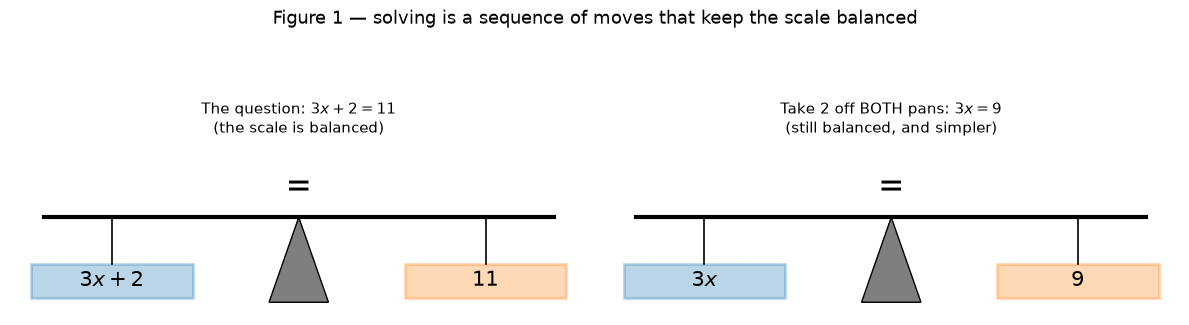

In [1]:
# --- Figure 1: an equation is a balance scale, and one legal move ---

import numpy as np                    # np = the fast-numbers tool (arrays and maths)
import matplotlib.pyplot as plt       # plt = matplotlib's drawing tool
from matplotlib.patches import Rectangle, Polygon   # ready-made shapes to draw with

# One colour code for the WHOLE notebook, so every picture speaks the same language:
C_MAIN = "#1f77b4"   # blue   -> the LEFT-hand side of an equation
C_ALT  = "#ff7f0e"   # orange -> the RIGHT-hand side of an equation
C_BAD  = "#d62728"   # red    -> something wrong / forbidden / a fake solution
C_OK   = "#2ca02c"   # green  -> the true solution
C_GREY = "#7f7f7f"   # grey   -> helper lines, axes, scaffolding


def draw_scale(ax, left_text, right_text, title):
    """Draw one balanced scale, with a label written on each pan."""
    # the stand: a triangle standing on the ground
    ax.add_patch(Polygon([(-0.35, 0.0), (0.35, 0.0), (0.0, 1.0)],
                         closed=True, facecolor=C_GREY, edgecolor="black"))
    # the beam: one horizontal bar sitting on top of the triangle
    ax.plot([-3.0, 3.0], [1.0, 1.0], color="black", linewidth=3.0)
    # the two pans: a rope down from each end of the beam, then a box
    for side, colour, text in ((-1, C_MAIN, left_text), (+1, C_ALT, right_text)):
        x_end = 2.2 * side                                                  # where it hangs
        ax.plot([x_end, x_end], [1.0, 0.45], color="black", linewidth=1.2)  # the rope
        ax.add_patch(Rectangle((x_end - 0.95, 0.05), 1.9, 0.4,              # the pan
                               facecolor=colour, alpha=0.30,
                               edgecolor=colour, linewidth=2))
        ax.text(x_end, 0.25, text, ha="center", va="center", fontsize=15)
    # the equals sign, written above the middle, where the beam is level
    ax.text(0.0, 1.35, "=", ha="center", va="center", fontsize=22)
    ax.set_title(title, fontsize=11)
    ax.set_xlim(-3.4, 3.4)
    ax.set_ylim(-0.15, 1.9)
    ax.set_aspect("equal")     # shape matters here, so lock the aspect ratio
    ax.axis("off")             # a scale has no axes


fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2))
draw_scale(axes[0], r"$3x+2$", r"$11$",
           "The question: $3x+2=11$\n(the scale is balanced)")
draw_scale(axes[1], r"$3x$", r"$9$",
           "Take $2$ off BOTH pans: $3x=9$\n(still balanced, and simpler)")
fig.suptitle("Figure 1 — solving is a sequence of moves that keep the scale balanced",
             fontsize=13)
plt.tight_layout()
plt.show()

### 1.3 Picture two: two machines, and where they agree

The balance picture is good for *doing*. This second picture is better for understanding
*how many answers there are*.

Read $5x-3 = 2x+9$ as **two machines**:

* machine $L$ takes $x$ and returns $5x-3$;
* machine $R$ takes $x$ and returns $2x+9$.

Feed the same $x$ into both. Usually they disagree. Solving the equation means:

> find every input $x$ where the two machines **agree**.

If we draw both outputs against $x$, each machine is a straight line, and "they agree" means
"the two lines are at the same height", which means **the lines cross**. So:

$$\text{solutions of } L(x)=R(x) \;\longleftrightarrow\; \text{crossing points of the two graphs.}$$

This one sentence is the bridge between *equations* (this chapter) and *functions* (a later
chapter). Everything we prove today has a picture, and this is the picture.

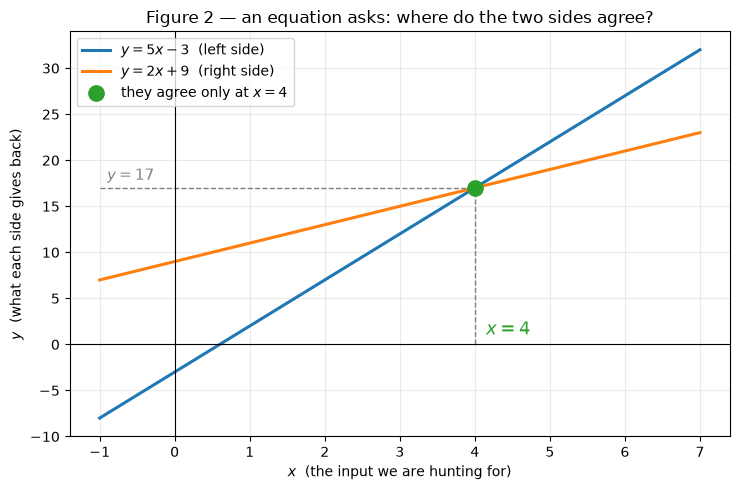

In [2]:
# --- Figure 2: solving 5x - 3 = 2x + 9 means finding where two lines cross ---

x = np.linspace(-1.0, 7.0, 400)       # 400 evenly spaced x-values from -1 to 7
L = 5 * x - 3                          # the LEFT machine, evaluated at every one of them
R = 2 * x + 9                          # the RIGHT machine, evaluated at every one of them

fig, ax = plt.subplots(figsize=(7.5, 5.0))
ax.plot(x, L, color=C_MAIN, linewidth=2.2, label=r"$y = 5x-3$  (left side)")
ax.plot(x, R, color=C_ALT,  linewidth=2.2, label=r"$y = 2x+9$  (right side)")

x_star = 4.0                           # the solution (we prove this in section 5)
y_star = 5 * x_star - 3                # the common height there: 17
ax.plot([x_star], [y_star], "o", color=C_OK, markersize=11, zorder=5,
        label=r"they agree only at $x=4$")
# dashed guide lines: down to the x-axis, and left to the y-axis
ax.plot([x_star, x_star], [0, y_star], "--", color=C_GREY, linewidth=1.0)
ax.plot([-1, x_star], [y_star, y_star], "--", color=C_GREY, linewidth=1.0)
ax.text(x_star + 0.15, 1.0, r"$x=4$", color=C_OK, fontsize=13)
ax.text(-0.9, y_star + 0.8, r"$y=17$", color=C_GREY, fontsize=11)

ax.axhline(0, color="black", linewidth=0.8)   # the x-axis
ax.axvline(0, color="black", linewidth=0.8)   # the y-axis
ax.set_xlabel("$x$  (the input we are hunting for)")
ax.set_ylabel("$y$  (what each side gives back)")
ax.set_title("Figure 2 — an equation asks: where do the two sides agree?")
ax.legend(loc="upper left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 1.4 A linear equation has only **three** possible answers

Two straight lines drawn in a plane can do exactly three things, and nothing else:

1. **cross once** — one solution;
2. **stay parallel and never meet** — no solution;
3. **be the very same line** — every $x$ is a solution.

There is no fourth option. Two *different* straight lines cannot cross twice: if they agreed
at two places they would already be the same line. (That is the identity theorem, nb 04
Theorem 9; you will prove the linear case yourself in Exercise 20.)

So before you even start calculating, you already know the *shape* of the answer:
**one, none, or all**. That is real knowledge. When your algebra ends in something like
$0=5$, you have not necessarily made a mistake — you may simply have landed in case 2, and
the honest answer is "no solution".

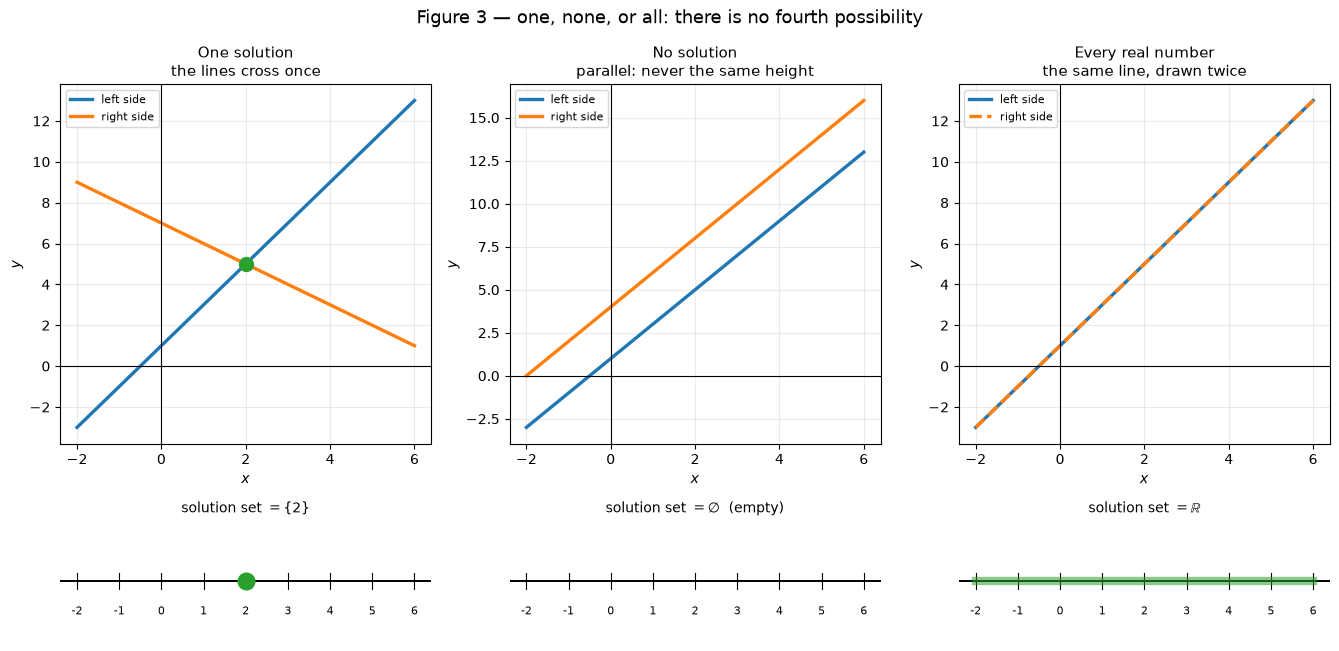

In [3]:
# --- Figure 3: the only three things a linear equation can do ---

fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.6),
                         gridspec_kw={"height_ratios": [3, 1]})
x = np.linspace(-2.0, 6.0, 400)

# Each column is one case: (left side values, right side values, title, explanation)
cases = [
    (2 * x + 1, -x + 7,    "One solution",      "the lines cross once"),
    (2 * x + 1, 2 * x + 4, "No solution",       "parallel: never the same height"),
    (2 * x + 1, 2 * x + 1, "Every real number", "the same line, drawn twice"),
]

for col, (Lvals, Rvals, title, subtitle) in enumerate(cases):
    ax = axes[0][col]
    ax.plot(x, Lvals, color=C_MAIN, linewidth=2.4, label="left side")
    # in the third case the two lines sit on top of each other,
    # so draw the second one dashed - otherwise you would only see one line
    ax.plot(x, Rvals, color=C_ALT, linewidth=2.4,
            linestyle="--" if col == 2 else "-", label="right side")
    if col == 0:                                  # mark the single crossing point
        ax.plot([2.0], [5.0], "o", color=C_OK, markersize=10, zorder=5)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title + "\n" + subtitle, fontsize=11)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc="upper left")

    # bottom row: the same answer drawn as a solution SET on a number line
    nl = axes[1][col]
    nl.axhline(0, color="black", linewidth=1.4)          # the number line itself
    for tick in range(-2, 7):                            # small ticks with labels
        nl.plot([tick, tick], [-0.12, 0.12], color="black", linewidth=0.8)
        nl.text(tick, -0.5, str(tick), ha="center", fontsize=8)
    if col == 0:
        nl.plot([2.0], [0.0], "o", color=C_OK, markersize=12)
        nl.set_title(r"solution set $=\{2\}$", fontsize=10)
    elif col == 1:
        nl.set_title(r"solution set $=\varnothing$  (empty)", fontsize=10)
    else:
        nl.plot(x, 0 * x, color=C_OK, linewidth=6, alpha=0.55)   # the whole line
        nl.set_title(r"solution set $=\mathbb{R}$", fontsize=10)
    nl.set_xlim(-2.4, 6.4)
    nl.set_ylim(-0.9, 0.9)
    nl.axis("off")

fig.suptitle("Figure 3 — one, none, or all: there is no fourth possibility", fontsize=13)
plt.tight_layout()
plt.show()

### 1.5 What "solving" really is

Here is the idea that makes the whole chapter make sense.

You cannot *see* the answer of $5x-3 = 2x+9$. But you can see the answer of $x = 4$
immediately. So solving is not "computing the answer". Solving is:

> **replacing a hard question by an easier question that has exactly the same answer**,
> again and again, until the question is so easy that you can read the answer off.

Two questions with the same solution set are called **equivalent**. A solution is therefore
a *chain*:

$$5x-3=2x+9 \;\Longleftrightarrow\; 3x-3=9 \;\Longleftrightarrow\; 3x=12
\;\Longleftrightarrow\; x=4 .$$

Every $\Longleftrightarrow$ in that chain is a **promise**: *the set of answers did not
change at this step*. Section 3 proves which moves are allowed to carry that promise — and,
just as important, which popular moves are **not**.

### 1.6 The plan of this notebook

1. definitions (§ 2) — equation, solution, solution set, equivalent, linear;
2. the two **safe** moves, proved (§ 3, Theorems 1–2);
3. the complete answer for a linear equation, proved (§ 3, Theorems 3–4);
4. the two **dangerous** moves, proved exactly — multiplying by something containing $x$
   (Theorem 6: fake solutions appear) and dividing by something containing $x$
   (Theorem 7: real solutions disappear);
5. traps (§ 4), worked examples (§ 5), Python (§ 6), and 20 exercises (§ 7).

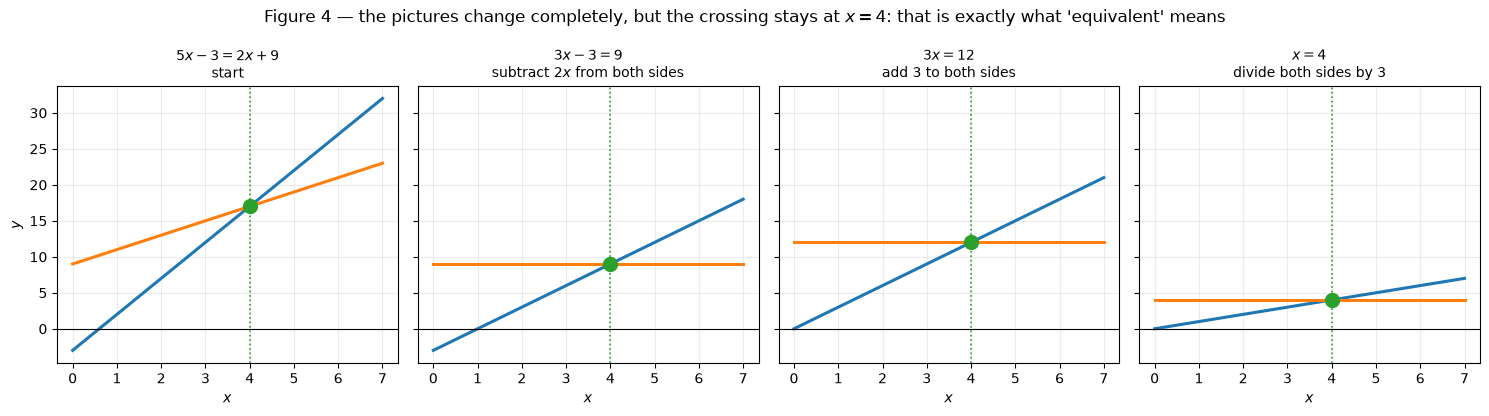

In [4]:
# --- Figure 4: a chain of equivalent equations - the crossing never moves ---

fig, axes = plt.subplots(1, 4, figsize=(15.0, 4.2), sharey=True)
x = np.linspace(0.0, 7.0, 400)

# The four questions in the chain: (left values, right values, the equation, the move made)
chain = [
    (5 * x - 3, 2 * x + 9,  r"$5x-3=2x+9$", "start"),
    (3 * x - 3, 0 * x + 9,  r"$3x-3=9$",    r"subtract $2x$ from both sides"),
    (3 * x,     0 * x + 12, r"$3x=12$",     r"add $3$ to both sides"),
    (x,         0 * x + 4,  r"$x=4$",       r"divide both sides by $3$"),
]

for ax, (Lvals, Rvals, name, move) in zip(axes, chain):
    ax.plot(x, Lvals, color=C_MAIN, linewidth=2.2)
    ax.plot(x, Rvals, color=C_ALT,  linewidth=2.2)
    i4 = np.argmin(np.abs(x - 4.0))          # the index of the x-value closest to 4
    ax.plot([4.0], [Lvals[i4]], "o", color=C_OK, markersize=10, zorder=5)
    ax.axvline(4.0, color=C_OK, linestyle=":", linewidth=1.2)   # always at x = 4
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(name + "\n" + move, fontsize=10)
    ax.set_xlabel("$x$")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("$y$")
fig.suptitle("Figure 4 — the pictures change completely, but the crossing stays at $x=4$: "
             "that is exactly what 'equivalent' means", fontsize=12)
plt.tight_layout()
plt.show()

---

## 2. Formal definitions

Every symbol used later is defined here. Read slowly; the whole chapter depends on
Definition 6.

> **Definition 1 (equation in one variable).**
> Let $L(x)$ and $R(x)$ be two expressions in the variable $x$. The writing
> $$L(x) = R(x)$$
> is called an **equation in one variable**. $L(x)$ is the **left-hand side** (LHS),
> $R(x)$ is the **right-hand side** (RHS).

> **Definition 2 (the domain of the equation).**
> Let $D_L$ be the domain of $L$ and $D_R$ the domain of $R$ (nb 02, § 2.3: the set of real
> numbers for which the recipe is legal). The **domain of the equation** is
> $$D = D_L \cap D_R,$$
> the numbers where **both** sides make sense. ($\cap$ means "intersection": the numbers in
> both sets at once.) Values outside $D$ are not wrong answers — the question cannot even be
> *asked* there.

> **Definition 3 (solution / root).**
> A number $r \in D$ is a **solution** (also called a **root**) of the equation if replacing
> $x$ by $r$ makes the two sides equal as numbers: $L(r) = R(r)$.

> **Definition 4 (solution set).**
> The **solution set** is
> $$S \;=\; \{\, x \in D \;:\; L(x) = R(x) \,\}.$$
> To **solve** an equation means to describe $S$ exactly — not to find "an answer", but to
> find *all* of them and prove there are no others.

> **Definition 5 (three kinds of equation).**
> * If $S = D$, the equation is an **identity**: true for every legal $x$.
> * If $S = \varnothing$, it is a **contradiction** (or *inconsistent*): true for no $x$.
> * Otherwise it is a **conditional equation**: true only on condition that $x$ is one of
>   some particular values.

> **Definition 6 (equivalent equations).**
> Two equations with the same domain $D$ are **equivalent** if they have **exactly the same
> solution set**. We write $\Longleftrightarrow$ between them.
>
> Note what this does *not* say. It does not say the equations look alike. $5x-3=2x+9$ and
> $x=4$ look nothing alike, yet they are equivalent, because both have solution set
> $\{4\}$. Equivalence is about the *answer*, never about the *appearance*.

> **Definition 7 (linear equation).**
> An equation is **linear in $x$** (also called a *first-degree* equation) if it can be
> written in the **standard form**
> $$ax + b = 0, \qquad a \neq 0,$$
> where $a$ and $b$ are real numbers that do not contain $x$. The condition $a\neq 0$ is part
> of the definition: if $a=0$ there is no $x$ left and the writing is not an equation *in*
> $x$ any more.

> **Definition 8 (an equation that *leads to* a linear equation).**
> Many equations are not linear as written — for example $\dfrac{x}{x-2} = \dfrac{2}{x-2}+2$
> — but become linear after legal rewriting. We call these *equations leading to a linear
> equation*. They are the interesting ones, because the rewriting is exactly where the danger
> lives (Theorems 6 and 7).

**A note on the word "linear".** It comes from *line*. Definition 7 will be tied to straight
lines properly in a later chapter; for now, Figures 2–4 are the reason for the word.

---

## 3. Theorems, with full proofs

### 3.1 The two safe moves

The balance picture said: *do the same thing to both sides*. Now we prove it. Everything
rests on the field axioms of $\mathbb{R}$ from notebook 01 — no new assumptions.

Throughout, $D$ is the domain of the equation (Definition 2), and $S$ its solution set.

---

> **Theorem 1 (the addition property of equality).**
> Let $L(x)=R(x)$ be an equation with domain $D$, and let $c(x)$ be an expression that is
> defined on the whole of $D$. Then
> $$L(x) = R(x) \qquad\Longleftrightarrow\qquad L(x) + c(x) = R(x) + c(x)$$
> — the two equations have exactly the same solution set.

**Proof.** Write $S_1$ for the solution set of the first equation and $S_2$ for the solution
set of the second. Both equations have domain $D$, because $c$ is defined everywhere on $D$
and adding never creates a new forbidden point. To prove $S_1 = S_2$ we prove two
inclusions — this is the standard way to prove two sets are equal (nb 01, § 3.1).

*Step 1: $S_1 \subseteq S_2$.* Let $r \in S_1$. Then $L(r)$ and $R(r)$ are the *same real
number*. Call it $t$. Then
$$L(r) + c(r) = t + c(r) = R(r) + c(r),$$
where both equalities hold because we substituted equal numbers into the same expression.
So $r$ satisfies the second equation, i.e. $r \in S_2$.

*Step 2: $S_2 \subseteq S_1$.* Let $r \in S_2$, so $L(r)+c(r) = R(r)+c(r)$. The real number
$c(r)$ has an **opposite** $-c(r)$ (the additive-inverse axiom, nb 01). Add it to both sides
— which is legal for *numbers*, since these are now plain real numbers and we are using
Step 1's reasoning at the level of arithmetic:
$$\bigl(L(r)+c(r)\bigr) + \bigl(-c(r)\bigr) = \bigl(R(r)+c(r)\bigr) + \bigl(-c(r)\bigr).$$
Use associativity on both sides, then $c(r) + (-c(r)) = 0$, then $u + 0 = u$:
$$L(r) + 0 = R(r) + 0 \quad\Longrightarrow\quad L(r) = R(r).$$
So $r \in S_1$.

Both inclusions hold, therefore $S_1 = S_2$. $\blacksquare$

**Where each hypothesis was used.** "$c$ defined on all of $D$" was used to say the two
equations have the *same* domain. Drop it and the theorem fails: adding $\frac{1}{x-5}$ to
both sides of $x = 5$ turns a question with the answer $\{5\}$ into a question that cannot
be asked at $x=5$ at all. The answer set changes from $\{5\}$ to $\varnothing$.

**Corollary 1a (subtraction).** Taking $c(x)$ to be $-d(x)$ gives: you may subtract the same
expression from both sides. In particular, *moving a term to the other side and changing its
sign* is not a separate rule — it is Theorem 1 used once.

---

> **Theorem 2 (the multiplication property of equality).**
> Let $L(x)=R(x)$ have domain $D$ and let $c$ be a **non-zero real number**. Then
> $$L(x) = R(x) \qquad\Longleftrightarrow\qquad c\,L(x) = c\,R(x).$$

**Proof.** Again two inclusions.

*Step 1 ($\Rightarrow$).* If $L(r) = R(r)$ as numbers, then multiplying the same number by
$c$ gives the same result: $cL(r) = cR(r)$. This direction did **not** use $c \neq 0$.

*Step 2 ($\Leftarrow$).* Suppose $cL(r) = cR(r)$. Because $c \neq 0$, the multiplicative
inverse $\frac1c$ exists (nb 01 field axioms). Multiply both sides by it:
$$\tfrac1c\bigl(c\,L(r)\bigr) = \tfrac1c\bigl(c\,R(r)\bigr).$$
By associativity, $\left(\tfrac1c \cdot c\right)L(r) = \left(\tfrac1c\cdot c\right)R(r)$,
i.e. $1\cdot L(r) = 1 \cdot R(r)$, i.e. $L(r)=R(r)$. $\blacksquare$

**Why $c \neq 0$ is not decoration.** Step 2 is the only place it was used, and it is exactly
the step that fails without it. Take $c=0$: the equation $x = 5$ becomes $0\cdot x = 0\cdot
5$, that is $0 = 0$ — an identity. The solution set jumped from $\{5\}$ to all of
$\mathbb{R}$. Multiplying by zero does not just lose *some* information; it loses *all* of
it. Figure 5 shows the crime happening.

**Corollary 2a (division).** Taking $c = \frac1d$ with $d \neq 0$: you may divide both sides
by any non-zero **number**. Read that word "number" carefully. Dividing by an *expression*
containing $x$ is a completely different move, and it is dangerous — Theorem 7.

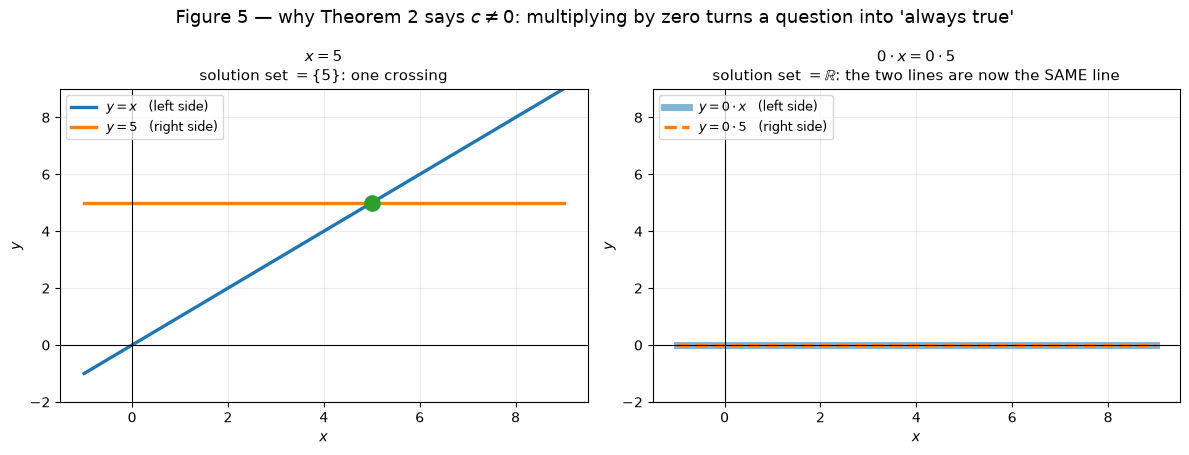

In [5]:
# --- Figure 5: multiplying both sides by zero destroys the question ---

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
x = np.linspace(-1.0, 9.0, 400)

# LEFT: the honest question  x = 5
axes[0].plot(x, x,        color=C_MAIN, linewidth=2.4, label=r"$y=x$   (left side)")
axes[0].plot(x, 0 * x + 5, color=C_ALT, linewidth=2.4, label=r"$y=5$   (right side)")
axes[0].plot([5.0], [5.0], "o", color=C_OK, markersize=11, zorder=5)
axes[0].set_title(r"$x = 5$" + "\nsolution set $=\\{5\\}$: one crossing", fontsize=11)

# RIGHT: the same equation after multiplying BOTH sides by 0
axes[1].plot(x, 0 * x, color=C_MAIN, linewidth=5.0, alpha=0.55,
             label=r"$y=0\cdot x$   (left side)")
axes[1].plot(x, 0 * x, color=C_ALT, linewidth=2.4, linestyle="--",
             label=r"$y=0\cdot 5$   (right side)")
axes[1].plot(x, 0 * x, color=C_BAD, linewidth=1.0, alpha=0.0)   # keeps the legend tidy
axes[1].set_title(r"$0\cdot x = 0\cdot 5$" +
                  "\nsolution set $=\\mathbb{R}$: the two lines are now the SAME line",
                  fontsize=11)

for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.set_ylim(-2.0, 9.0)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", fontsize=9)

fig.suptitle("Figure 5 — why Theorem 2 says $c \\neq 0$: "
             "multiplying by zero turns a question into 'always true'", fontsize=13)
plt.tight_layout()
plt.show()

### 3.2 The complete answer for a linear equation

Theorems 1 and 2 tell us which moves are safe. Now we use them to answer the question
completely — not "here is a method", but "here is the answer, and there is no other".

---

> **Theorem 3 (existence and uniqueness).**
> Let $a, b$ be real numbers with $a \neq 0$. Then the equation
> $$ax + b = 0$$
> has **exactly one** real solution, namely
> $$x = -\frac{b}{a}.$$

**Proof.** "Exactly one" is two claims, and each needs its own argument.

*Existence — there is at least one.* Substitute $x = -\frac{b}{a}$ into the left side:
$$a\left(-\frac{b}{a}\right) + b
 = -\left(a\cdot\frac{b}{a}\right) + b
 = -\left(\frac{a}{a}\cdot b\right) + b
 = -(1\cdot b) + b
 = -b + b = 0 .$$
Every step is a field axiom: sign rules (nb 01 Theorem C), associativity and commutativity of
multiplication, $\frac{a}{a}=1$ (legal because $a\neq 0$), $1\cdot b = b$, and
$-b+b=0$. So $-\frac{b}{a}$ *is* a solution. Note that this step already needs $a \neq 0$ —
otherwise the number $-\frac{b}{a}$ does not even exist.

*Uniqueness — there is at most one.* Suppose $r$ and $s$ are both solutions. Then
$$ar + b = 0 \qquad\text{and}\qquad as + b = 0 .$$
Subtract the second from the first (Theorem 1, at the level of numbers):
$$(ar+b) - (as+b) = 0 - 0 = 0 .$$
Expand the left side and cancel $b$ against $-b$:
$$ar - as = 0 \quad\Longrightarrow\quad a(r-s) = 0,$$
using the distributive axiom backwards. Now apply the **zero-product property**
(nb 01 Theorem B): $a(r-s)=0$ forces $a = 0$ **or** $r-s=0$. We assumed $a \neq 0$, so the
first option is closed. Therefore $r - s = 0$, and adding $s$ to both sides gives $r = s$.

So there is at least one solution and at most one solution: exactly one. $\blacksquare$

**Read that proof again and notice the shape.** It is the *three-line uniqueness pattern* we
named in notebook 08: assume two answers, subtract them, and use a rule that says
"only zero can do that". You have now seen it in roots (nb 08) and in equations (here). It
will come back in every chapter.

---

> **Theorem 4 (what happens when $a = 0$).**
> Consider $ax + b = 0$ with $a = 0$, i.e. the writing $0\cdot x + b = 0$.
> * If $b \neq 0$: the solution set is $\varnothing$ (no solution).
> * If $b = 0$: the solution set is $\mathbb{R}$ (every real number).

**Proof.** By nb 01 Theorem A, $0 \cdot x = 0$ for every real $x$, so the left side equals
$0 + b = b$ whatever $x$ is. The equation is therefore the statement $b = 0$, which does not
mention $x$ at all. If $b \neq 0$ that statement is false, so no $x$ works and $S =
\varnothing$. If $b = 0$ that statement is true, so every $x \in \mathbb{R}$ works and
$S = \mathbb{R}$. $\blacksquare$

---

> **Theorem 5 (the trichotomy for linear equations).**
> Let $p, q, r, s$ be real numbers and consider
> $$p x + q = r x + s .$$
> Exactly one of these three cases holds:
> 1. if $p \neq r$: exactly one solution, $x = \dfrac{s-q}{p-r}$;
> 2. if $p = r$ and $q \neq s$: no solution ($S=\varnothing$);
> 3. if $p = r$ and $q = s$: every real number is a solution ($S=\mathbb{R}$).

**Proof.** By Theorem 1 (subtract $rx$ and subtract $q$ from both sides — both are defined
everywhere, so the solution set does not change), the equation is *equivalent* to
$$(p-r)x + (q-s) = 0 .$$
This is the standard form $ax+b=0$ with $a = p-r$ and $b = q-s$.

* If $p \neq r$ then $a \neq 0$, and Theorem 3 gives exactly one solution,
  $x = -\frac{b}{a} = -\frac{q-s}{p-r} = \frac{s-q}{p-r}$.
* If $p = r$ then $a = 0$, and Theorem 4 applies: no solution when $b = q-s \neq 0$, all of
  $\mathbb{R}$ when $b = q - s = 0$.

The three cases exclude each other and cover everything, so exactly one holds.
$\blacksquare$

**This theorem is the proof of Figure 3.** "One, none, or all" is not an observation about
pictures — it is a theorem, and now you have seen why there is no fourth case: the whole
argument collapses into $ax+b=0$, and a single number $a$ is either zero or not.

### 3.3 The two dangerous moves

Theorems 1 and 2 are safe because they can be *undone*: adding $c$ is undone by subtracting
$c$; multiplying by $c \neq 0$ is undone by dividing by $c$. A move you can undo cannot
change the answer.

Now we look at the two moves that **cannot always be undone**. This is the heart of the
notebook, and the debt we owe from notebook 08.

---

> **Theorem 6 (multiplying by an expression: fake solutions appear).**
> Let $L(x) = R(x)$ have domain $D$, and let $E(x)$ be an expression defined on $D$. Write
> $$S \;=\;\{x \in D : L(x)=R(x)\}, \qquad
>   S' \;=\;\{x \in D : E(x)L(x)=E(x)R(x)\},\qquad
>   Z \;=\;\{x\in D : E(x)=0\}.$$
> Then
> $$\boxed{\,S' \;=\; S \,\cup\, Z\,}$$
> In words: multiplying both sides by $E(x)$ **never loses a solution**, and the solutions it
> **adds** are exactly the zeros of $E$ — no more, no less.

**Proof.** Two inclusions again.

*Step 1: $S \cup Z \subseteq S'$.* Take $r \in D$.
If $r \in S$ then $L(r) = R(r)$, so multiplying the same number by $E(r)$ gives
$E(r)L(r) = E(r)R(r)$, hence $r \in S'$.
If $r \in Z$ then $E(r) = 0$, so both sides are $0\cdot L(r) = 0$ and $0 \cdot R(r) = 0$ by
nb 01 Theorem A. They are equal, so again $r \in S'$ — *even though $L(r)$ and $R(r)$ may be
completely different numbers*. That is precisely how a fake solution is born.

*Step 2: $S' \subseteq S \cup Z$.* Let $r \in S'$, so $E(r)L(r) = E(r)R(r)$. Subtract the
right side from the left (Theorem 1) and factor with the distributive axiom:
$$E(r)L(r) - E(r)R(r) = 0
 \quad\Longrightarrow\quad E(r)\bigl(L(r)-R(r)\bigr) = 0 .$$
Now the **zero-product property** (nb 01 Theorem B): a product of two real numbers is zero
only if one of them is zero. So $E(r) = 0$ — that is $r \in Z$ — or $L(r)-R(r)=0$, that is
$L(r)=R(r)$, that is $r \in S$. Either way $r \in S \cup Z$.

Both inclusions hold, so $S' = S \cup Z$. $\blacksquare$

**Corollary 6a (the checking rule, now a theorem).**
Suppose you solve an equation by multiplying both sides by $E(x)$ and you obtain the
candidate set $S'$. Then
$$S \;=\; \{\, r \in S' \;:\; E(r) \neq 0 \text{ and } r \in D \,\}.$$
So the "check your answers" step is **not** a safety habit and **not** politeness. It is the
second half of the proof. Without it you have not solved the equation; you have only found a
set that *contains* the solutions.

**Corollary 6b (why squaring invents solutions).** Squaring is the same phenomenon in
disguise. From $L = R$ we get $L^2 = R^2$, and going back, $L^2 - R^2 = (L-R)(L+R) = 0$ gives
$L = R$ **or** $L = -R$. So squaring returns the union of the solutions of $L=R$ and of
$L=-R$; the extra ones come from the second equation. This is exactly the promise made in
notebook 08, Trap 7, and it is why $\sqrt{x} = -3$ has no solution while its square
$x = 9$ does. (Radical equations get their own topic, § 4 of this chapter.)

---

> **Theorem 7 (dividing by an expression: real solutions disappear).**
> With the notation of Theorem 6, suppose $E(x) L(x) = E(x) R(x)$ and we "cancel $E$".
> Then the solution set shrinks from $S \cup Z$ to $S$: **every zero of $E$ that was a
> genuine solution is lost.**

**Proof.** This is Theorem 6 read from right to left; nothing new is needed. The point is
the practical consequence: if $x=c$ satisfies $E(c) = 0$ *and* is a genuine solution of the
original equation, cancelling $E$ deletes it from the answer, and no amount of checking
afterwards will bring it back — you would have to notice that you never wrote it down.
$\blacksquare$

**The rule you should carry for life.**

| Move | Safe? | What can go wrong | What to do |
| --- | --- | --- | --- |
| add / subtract an expression defined everywhere on $D$ | **safe** | nothing | nothing |
| multiply / divide by a non-zero **number** | **safe** | nothing | nothing |
| multiply both sides by an expression $E(x)$ | dangerous | **extra** fake solutions at the zeros of $E$ | check every candidate in the **original** equation |
| divide both sides by an expression $E(x)$ | dangerous | **lost** real solutions at the zeros of $E$ | never divide — **factor** and use the zero-product property instead |
| square both sides | dangerous | extra solutions from $L=-R$ | check every candidate |

The two dangerous rows have opposite dangers, and there is a way to remember which is which:
multiplying makes the equation *bigger*, so the answer set gets bigger too (fake extras);
dividing makes it *smaller*, so the answer set gets smaller too (lost real ones).

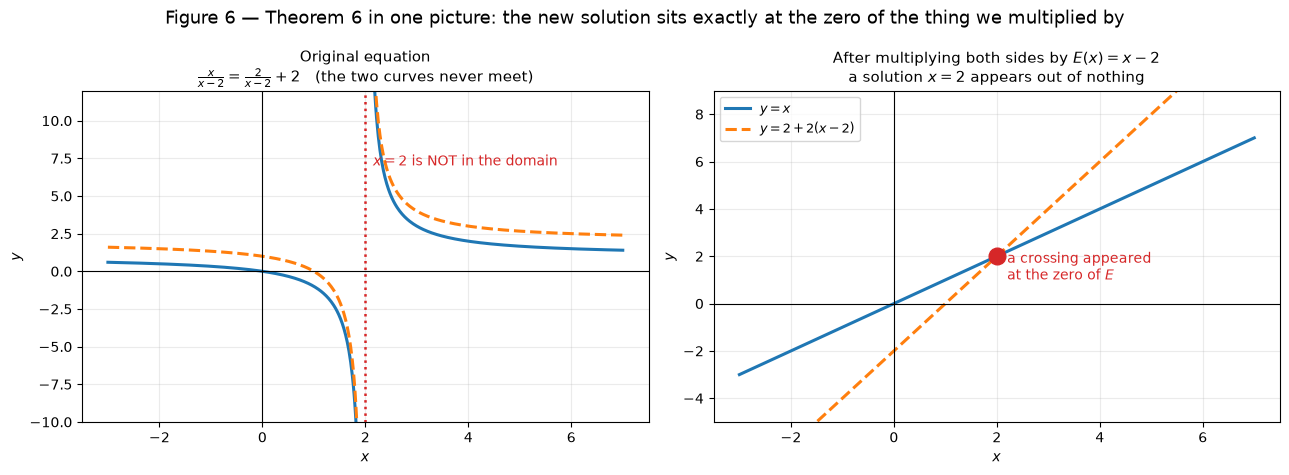

In [6]:
# --- Figure 6: watching a fake solution being born ---
# The equation:  x/(x-2) = 2/(x-2) + 2      -- domain: every real number EXCEPT x = 2
# Multiply both sides by E(x) = x - 2:  x = 2 + 2(x-2), which is linear and gives x = 2.
# But x = 2 is forbidden in the original. It is a zero of E, exactly as Theorem 6 predicts.

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

# Draw the ORIGINAL equation. Both sides blow up at x = 2, so plot left and right of it
# separately - otherwise matplotlib draws a fake vertical line joining the two branches.
for piece in (np.linspace(-3.0, 1.93, 300), np.linspace(2.07, 7.0, 300)):
    axes[0].plot(piece, piece / (piece - 2), color=C_MAIN, linewidth=2.2)
    axes[0].plot(piece, 2 / (piece - 2) + 2, color=C_ALT, linewidth=2.2, linestyle="--")
axes[0].axvline(2.0, color=C_BAD, linestyle=":", linewidth=1.8)   # the forbidden wall
axes[0].text(2.15, 7.0, r"$x=2$ is NOT in the domain", color=C_BAD, fontsize=10)
axes[0].set_title("Original equation\n" +
                  r"$\frac{x}{x-2}=\frac{2}{x-2}+2$   (the two curves never meet)",
                  fontsize=11)
axes[0].set_ylim(-10, 12)

# Draw the equation AFTER multiplying by (x - 2): now both sides are polynomials.
x = np.linspace(-3.0, 7.0, 400)
axes[1].plot(x, x, color=C_MAIN, linewidth=2.2, label=r"$y=x$")
axes[1].plot(x, 2 + 2 * (x - 2), color=C_ALT, linewidth=2.2, linestyle="--",
             label=r"$y=2+2(x-2)$")
axes[1].plot([2.0], [2.0], "o", color=C_BAD, markersize=12, zorder=5)
axes[1].text(2.2, 1.0, "a crossing appeared\nat the zero of $E$", color=C_BAD, fontsize=10)
axes[1].set_title("After multiplying both sides by $E(x)=x-2$\n" +
                  "a solution $x=2$ appears out of nothing", fontsize=11)
axes[1].set_ylim(-5, 9)
axes[1].legend(loc="upper left", fontsize=9)

for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.grid(alpha=0.25)

fig.suptitle("Figure 6 — Theorem 6 in one picture: the new solution sits exactly "
             "at the zero of the thing we multiplied by", fontsize=13)
plt.tight_layout()
plt.show()

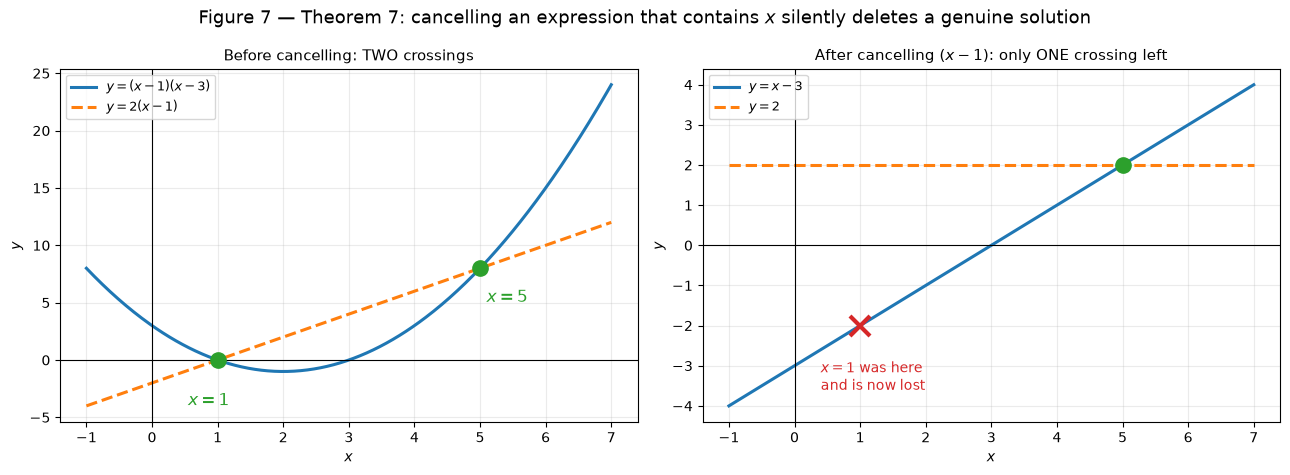

In [7]:
# --- Figure 7: the opposite crime - dividing by (x-1) deletes a real solution ---
# Equation:  (x-1)(x-3) = (x-1)*2      Both sides are honest polynomials, domain = R.
# Correct method: bring everything to one side and FACTOR:
#     (x-1)(x-3) - (x-1)*2 = (x-1)(x-5) = 0  ->  x = 1 or x = 5.
# Wrong method: "cancel (x-1)" -> x-3 = 2 -> x = 5 only. The solution x = 1 is gone.

x = np.linspace(-1.0, 7.0, 400)
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))

axes[0].plot(x, (x - 1) * (x - 3), color=C_MAIN, linewidth=2.2,
             label=r"$y=(x-1)(x-3)$")
axes[0].plot(x, (x - 1) * 2, color=C_ALT, linewidth=2.2, linestyle="--",
             label=r"$y=2(x-1)$")
axes[0].plot([1.0, 5.0], [0.0, 8.0], "o", color=C_OK, markersize=11, zorder=5)
axes[0].text(0.55, -4.0, r"$x=1$", color=C_OK, fontsize=12)
axes[0].text(5.1, 5.0, r"$x=5$", color=C_OK, fontsize=12)
axes[0].set_title("Before cancelling: TWO crossings", fontsize=11)

axes[1].plot(x, x - 3, color=C_MAIN, linewidth=2.2, label=r"$y=x-3$")
axes[1].plot(x, 0 * x + 2, color=C_ALT, linewidth=2.2, linestyle="--", label=r"$y=2$")
axes[1].plot([5.0], [2.0], "o", color=C_OK, markersize=11, zorder=5)
axes[1].plot([1.0], [-2.0], "x", color=C_BAD, markersize=14, markeredgewidth=3, zorder=5)
axes[1].text(0.4, -3.6, "$x=1$ was here\nand is now lost", color=C_BAD, fontsize=10)
axes[1].set_title(r"After cancelling $(x-1)$: only ONE crossing left", fontsize=11)

for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", fontsize=9)

fig.suptitle("Figure 7 — Theorem 7: cancelling an expression that contains $x$ "
             "silently deletes a genuine solution", fontsize=13)
plt.tight_layout()
plt.show()

---

## 4. The traps (read this section twice)

**Trap 1 — dividing by something that might be zero.**
From $(x-1)(x-3) = 2(x-1)$, cancelling $(x-1)$ gives $x=5$ and throws away $x=1$
(Figure 7). *Never cancel a bracket containing $x$.* Move everything to one side, factor,
and use the zero-product property.

**Trap 2 — forgetting the domain before you start.**
$\dfrac{x}{x-2} = \dfrac{2}{x-2} + 2$ has domain $\mathbb{R}\setminus\{2\}$. Write that down
*first*, before any algebra. Then when the candidate $x=2$ appears, you already know it is
dead. (Deciding the domain *after* seeing the answer is how people talk themselves into
keeping a fake solution.)

**Trap 3 — treating "check your answer" as optional.**
Corollary 6a proved it is half of the argument. If you multiplied by anything containing
$x$, an unchecked answer is not an answer.

**Trap 4 — checking in the *wrong* equation.**
The check must be done in the **original** equation, not in the tidy one you produced three
lines later. A fake solution satisfies every equation after the dangerous step — that is
what makes it fake. Checking there proves nothing.

**Trap 5 — the disappearing minus sign in front of a fraction.**
$-\dfrac{x-3}{4}$ means $\dfrac{-(x-3)}{4} = \dfrac{-x+3}{4}$, not $\dfrac{-x-3}{4}$.
This is nb 07 Trap 5 again, and it is still the most common arithmetic slip when clearing
denominators.

**Trap 6 — multiplying only *some* terms by the LCD.**
When you clear denominators, the LCD multiplies **every single term**, including the terms
that had no fraction at all. In $\frac{x}{3} - \frac{x-2}{4} = \frac{1}{6}$ the right-hand
side is a term too.

**Trap 7 — thinking $0 = 5$ means "I made a mistake".**
It usually means case 2 of Theorem 5: no solution. Equally, $0 = 0$ usually means case 3:
every real number. Both are *answers*, and you should write them as sets:
$S=\varnothing$, $S=\mathbb{R}$.

**Trap 8 — writing "$x = $" when the answer is a set.**
If every real number works, "$x = $ all numbers" is sloppy. Write $S = \mathbb{R}$. If
nothing works, do not write "$x = \varnothing$" (that says $x$ is a set!); write
$S = \varnothing$.

**Trap 9 — squaring both sides and relaxing.**
Corollary 6b: squaring merges $L=R$ with $L=-R$. Every candidate must be checked. We will
meet this properly in § 4 of this chapter (*Radical Equations*), but the theorem is already
proved, today.

---

## 5. Worked examples

Every example below follows the same discipline, and you should copy it:

1. **state the domain $D$** before touching anything;
2. do the algebra, and after each step say *which theorem* allowed it;
3. **check** whenever a dangerous move (Theorem 6 or 7) was used;
4. write the answer as a **set**.

---

### Example 1 — the simplest one, with every step named: $3x+5=11$

Domain: both sides are polynomials, so $D = \mathbb{R}$.

| Step | Equation | Why it is allowed |
| --- | --- | --- |
| start | $3x+5=11$ | |
| add $-5$ to both sides | $3x = 6$ | Theorem 1 (with $c=-5$, defined everywhere) |
| multiply both sides by $\tfrac13$ | $x = 2$ | Theorem 2 (with $c=\tfrac13 \neq 0$) |

Only safe moves were used, so the chain is a chain of $\Longleftrightarrow$ and
$$S=\{2\}.$$
Check anyway (it costs nothing): $3(2)+5 = 6+5 = 11$. ✓

---

### Example 2 — variables on both sides: $5x-3 = 2x+9$

Domain $D=\mathbb{R}$. This is the equation of Figures 2 and 4.

$$5x-3=2x+9
\;\overset{\text{Thm 1}}{\Longleftrightarrow}\; 3x-3 = 9
\;\overset{\text{Thm 1}}{\Longleftrightarrow}\; 3x = 12
\;\overset{\text{Thm 2}}{\Longleftrightarrow}\; x = 4 .$$

$S=\{4\}$. Check: $5(4)-3 = 17$ and $2(4)+9=17$. ✓

Alternatively, use Theorem 5 directly with $p=5,\,q=-3,\,r=2,\,s=9$: since $p \neq r$,
$x=\frac{s-q}{p-r} = \frac{9-(-3)}{5-2} = \frac{12}{3} = 4$. Same answer, no steps — that is
what a theorem buys you.

---

### Example 3 — brackets first: $5(x-3)+2 = 3(2x+1)-4$

Domain $D=\mathbb{R}$. Expand each side using the distributive axiom (this is *not* an
equation move; it is rewriting one side into an equal expression, so it can never change the
answer):

$$\text{LHS} = 5x-15+2 = 5x-13, \qquad \text{RHS} = 6x+3-4 = 6x-1 .$$

So $5x-13 = 6x-1$. Subtract $5x$ (Thm 1): $-13 = x-1$. Add $1$ (Thm 1): $-12 = x$.

$S = \{-12\}$. Check: LHS $=5(-15)+2 = -73$; RHS $=3(-23)-4 = -73$. ✓

> Notice: the variable ended up on the **right**. That is fine. $-12 = x$ and $x = -12$ are
> the same statement; $=$ is symmetric (nb 01).

---

### Example 4 — fractions: $\dfrac{x}{3} - \dfrac{x-2}{4} = \dfrac{1}{6}$

Domain $D = \mathbb{R}$ (the denominators are *numbers*, not expressions containing $x$ — so
nothing is forbidden and there is no danger here).

The LCD of $3, 4, 6$ is $12$ (nb 07 § 3.8). Multiply **every term** by $12$; this is
Theorem 2 with $c = 12 \neq 0$, so it is completely safe:

$$12\cdot\frac{x}{3} \;-\; 12\cdot\frac{x-2}{4} \;=\; 12\cdot\frac16
\quad\Longleftrightarrow\quad 4x - 3(x-2) = 2 .$$

Watch the minus sign in front of the bracket (Trap 5):
$4x - 3x + 6 = 2 \Longleftrightarrow x + 6 = 2 \Longleftrightarrow x = -4$.

$S=\{-4\}$. Check: $\frac{-4}{3} - \frac{-4-2}{4} = -\frac43 + \frac{6}{4}
= -\frac{8}{6} + \frac{9}{6} = \frac16$. ✓

---

### Example 5 — decimals: $0.06x + 0.09(x-4) = 0.51$

Domain $D=\mathbb{R}$. Decimals are just fractions, so use Theorem 2 with $c=100$ to make
them whole numbers:

$$6x + 9(x-4) = 51 \Longleftrightarrow 6x+9x-36 = 51 \Longleftrightarrow 15x = 87
\Longleftrightarrow x = \frac{87}{15} = \frac{29}{5} = 5.8 .$$

$S=\{5.8\}$. Check: $0.06(5.8) = 0.348$, $0.09(1.8) = 0.162$, and
$0.348+0.162 = 0.51$. ✓

---

### Example 6 — an identity: $3(2x-1)+4 = 6x+1$

Domain $D=\mathbb{R}$. Expand the left: $6x-3+4 = 6x+1$. The two sides are the *same
expression*. By Theorem 5 case 3 ($p=r=6$ and $q=s=1$),
$$S = \mathbb{R}.$$
Every real number is a solution. The two lines of Figure 3 (right panel) lie on top of each
other.

---

### Example 7 — a contradiction: $4(x-2) = 4x+1$

Domain $D=\mathbb{R}$. Expand: $4x-8 = 4x+1$. Subtract $4x$ (Thm 1): $-8 = 1$, which is
false. By Theorem 5 case 2 ($p=r=4$, $q=-8 \neq 1=s$),
$$S=\varnothing .$$
Do **not** write "$x=\varnothing$" (Trap 8). And do not panic at $-8=1$ (Trap 7): it is the
answer, not an error.

---

### Example 8 — a rational equation whose only candidate is fake

$$\frac{x}{x-2} \;=\; \frac{2}{x-2} + 2 .$$

**Domain first.** The denominator $x-2$ is zero at $x=2$, so
$D = \mathbb{R}\setminus\{2\}$ — write this down *now*, before any algebra (Trap 2).

Multiply both sides by $E(x) = x-2$. This is the **dangerous move** of Theorem 6, so from
here on every answer is only a *candidate*:

$$x \;=\; 2 + 2(x-2) \quad\Longleftrightarrow\quad x = 2x-2
\quad\Longleftrightarrow\quad -x = -2 \quad\Longleftrightarrow\quad x = 2 .$$

**Check (Corollary 6a).** Is $2 \in D$? No — $E(2)=0$. So the candidate is exactly one of
the fake solutions Theorem 6 warned about, and it must be thrown away. Nothing is left:

$$S = \varnothing .$$

Figure 6 shows why: the two original curves are always exactly $1$ apart
$\left(\frac{x}{x-2}-\frac{2}{x-2}-2 = 1-2 = -1\right)$, so they truly never meet.

---

### Example 9 — a rational equation with a genuine solution

$$\frac{3}{x+2} = \frac{1}{x-1}.$$

**Domain:** $D = \mathbb{R}\setminus\{-2,\,1\}$.

Multiply by $E(x) = (x+2)(x-1)$ — dangerous move again, so candidates only:

$$3(x-1) = x+2 \Longleftrightarrow 3x-3 = x+2 \Longleftrightarrow 2x = 5
\Longleftrightarrow x = \tfrac52 .$$

**Check:** $\tfrac52 \in D$ (it is neither $-2$ nor $1$), and in the original equation
$\frac{3}{5/2+2} = \frac{3}{9/2} = \frac23$ while $\frac{1}{5/2-1} = \frac{1}{3/2} =
\frac23$. ✓

$$S = \left\{\tfrac52\right\}.$$

> The move "$3(x-1) = x+2$" is often taught as *cross-multiplication*. It is not a separate
> rule — it is Theorem 6 with $E(x)=(x+2)(x-1)$, and it carries the same obligation to check.

---

### Example 10 — it looks quadratic, but it is linear: $(x+3)^2 = x^2+5$

Domain $D=\mathbb{R}$. Expand the left side (nb 04 Theorem 3, the perfect-square product):

$$x^2 + 6x + 9 = x^2 + 5 .$$

Subtract $x^2$ from both sides (Theorem 1 — $x^2$ is defined everywhere, so this is safe):

$$6x+9 = 5 \Longleftrightarrow 6x = -4 \Longleftrightarrow x = -\tfrac23 .$$

$S = \left\{-\tfrac23\right\}$. Check: $\left(-\tfrac23+3\right)^2 = \left(\tfrac73\right)^2
= \tfrac{49}{9}$ and $\tfrac49 + 5 = \tfrac{49}{9}$. ✓

**The lesson:** "linear" is a property of the equation *after* simplification, not of how it
looks on the page. Definition 7 says *can be written in the form* $ax+b=0$.

---

### Example 11 — literal equations (solve for a letter, not a number)

Here $x$ is not the unknown; some other letter is. Nothing changes: treat every other letter
as a fixed number and use the same two theorems.

**(a)** Solve $A = P(1+rt)$ for $r$ (this is the simple-interest formula: $A$ is the amount,
$P$ the starting money, $r$ the rate, $t$ the time).

Assume $P \neq 0$ and $t \neq 0$ — say it out loud, because Theorem 2 requires it.

$$A = P + Prt \;\overset{\text{Thm 1}}{\Longleftrightarrow}\; A - P = Prt
\;\overset{\text{Thm 2}}{\Longleftrightarrow}\; r = \frac{A-P}{Pt}.$$

**(b)** Solve $F = \tfrac95 C + 32$ for $C$ (Fahrenheit to Celsius).

$$F - 32 = \tfrac95 C \;\overset{\text{Thm 2},\ c=\frac59}{\Longleftrightarrow}\;
C = \tfrac59 (F-32).$$

Sanity check: $F=212$ gives $C = \frac59(180) = 100$. Water boils. ✓

---

### Example 12 — an equation with a parameter: all three cases at once

Solve for $x$, where $k$ is a fixed but unknown real number:

$$k^2 x + k \;=\; 4x + 2 .$$

Collect (Theorem 1): $k^2x - 4x = 2-k$, that is $(k^2-4)\,x = 2-k$, that is
$$(k-2)(k+2)\,x = -(k-2).$$

Now the coefficient $a = (k-2)(k+2)$ is zero exactly when $k=2$ or $k=-2$, so split into the
three cases of Theorem 5:

* **$k = 2$:** the equation reads $0\cdot x = 0$. By Theorem 4, $S = \mathbb{R}$.
* **$k = -2$:** the equation reads $0 \cdot x = 4$. By Theorem 4, $S = \varnothing$.
* **any other $k$:** $a \neq 0$, so by Theorem 3 there is exactly one solution
  $$x = \frac{-(k-2)}{(k-2)(k+2)} = \frac{-1}{k+2},$$
  where the cancellation of $(k-2)$ is legal *precisely because* we are in the case
  $k \neq 2$.

One equation, and all three shapes of Theorem 5 appear inside it, depending on $k$. This is
the most important example in the notebook: it shows that "how many solutions?" is a real
question with a real answer, not a formality.

---

### Example 13 — a first word problem

> A rectangle is $3$ cm longer than twice its width. Its perimeter is $36$ cm. Find its
> sides.

**Translate.** Let $w$ be the width in cm. "Length is 3 more than twice the width" means
$\ell = 2w+3$. The perimeter of a rectangle is $P = 2\ell + 2w$ (nb 03). So

$$2(2w+3) + 2w = 36 .$$

**Solve.** $4w+6+2w = 36 \Longleftrightarrow 6w = 30 \Longleftrightarrow w = 5$.

**Answer in the language of the question** (not just a number): the width is $5$ cm and the
length is $2(5)+3 = 13$ cm.

**Check in the original words, not in your own equation:** is $13$ three more than twice
$5$? $2(5)+3 = 13$ ✓. Is the perimeter $2(13)+2(5) = 36$? ✓

> A hidden restriction: a width must be positive, so really $D = (0,\infty)$, not
> $\mathbb{R}$. Here $w=5>0$, so we are fine — but in a later problem the algebra will hand
> you a negative length, and then "no solution" is the correct answer.

In [8]:
# --- Checking every worked example with SymPy (never trust algebra you have not tested) ---

import sympy as sp                    # sp = the symbolic-maths tool: it does algebra exactly

x, k = sp.symbols("x k")              # create two symbols; sympy now treats them as letters

# sp.Eq(left, right) builds an EQUATION object. Writing "left == right" would only ask
# Python whether the two expressions look identical - a completely different question.
examples = [
    ("Ex 1 : 3x+5=11",              sp.Eq(3*x + 5, 11)),
    ("Ex 2 : 5x-3=2x+9",            sp.Eq(5*x - 3, 2*x + 9)),
    ("Ex 3 : 5(x-3)+2=3(2x+1)-4",   sp.Eq(5*(x - 3) + 2, 3*(2*x + 1) - 4)),
    ("Ex 4 : x/3-(x-2)/4=1/6",      sp.Eq(x/3 - (x - 2)/sp.Integer(4), sp.Rational(1, 6))),
    ("Ex 5 : 0.06x+0.09(x-4)=0.51", sp.Eq(sp.Rational(6, 100)*x
                                          + sp.Rational(9, 100)*(x - 4),
                                          sp.Rational(51, 100))),
    ("Ex 6 : 3(2x-1)+4=6x+1",       sp.Eq(3*(2*x - 1) + 4, 6*x + 1)),
    ("Ex 7 : 4(x-2)=4x+1",          sp.Eq(4*(x - 2), 4*x + 1)),
    ("Ex 8 : x/(x-2)=2/(x-2)+2",    sp.Eq(x/(x - 2), 2/(x - 2) + 2)),
    ("Ex 9 : 3/(x+2)=1/(x-1)",      sp.Eq(3/(x + 2), 1/(x - 1))),
    ("Ex 10: (x+3)^2=x^2+5",        sp.Eq((x + 3)**2, x**2 + 5)),
]

print(f"{'equation':32} {'solution set found by SymPy'}")
print("-" * 72)
for name, equation in examples:
    # solveset(...) returns a SET, which is the honest answer shape (Definition 4).
    # domain=sp.S.Reals tells SymPy we only care about real numbers.
    answer = sp.solveset(equation, x, domain=sp.S.Reals)
    print(f"{name:32} {answer}")

equation                         solution set found by SymPy
------------------------------------------------------------------------
Ex 1 : 3x+5=11                   {2}
Ex 2 : 5x-3=2x+9                 {4}
Ex 3 : 5(x-3)+2=3(2x+1)-4        {-12}
Ex 4 : x/3-(x-2)/4=1/6           {-4}
Ex 5 : 0.06x+0.09(x-4)=0.51      {29/5}
Ex 6 : 3(2x-1)+4=6x+1            Reals
Ex 7 : 4(x-2)=4x+1               EmptySet
Ex 8 : x/(x-2)=2/(x-2)+2         EmptySet
Ex 9 : 3/(x+2)=1/(x-1)           {5/2}
Ex 10: (x+3)^2=x^2+5             {-2/3}


In [9]:
# --- Example 11 (literal) and Example 12 (parameter), done symbolically ---

A, P, r, t, F, C = sp.symbols("A P r t F C", real=True)

# Example 11(a): solve A = P(1 + r t) for r.
# sp.solve(equation, unknown) returns a LIST of solutions.
sol_r = sp.solve(sp.Eq(A, P*(1 + r*t)), r)
print("Ex 11(a)  r =", sol_r[0])

# Example 11(b): solve F = (9/5)C + 32 for C.
sol_C = sp.solve(sp.Eq(F, sp.Rational(9, 5)*C + 32), C)
print("Ex 11(b)  C =", sp.simplify(sol_C[0]),
      "  and at F = 212 that gives C =", sol_C[0].subs(F, 212))

print()
print("Ex 12:  k^2 x + k = 4x + 2, one case at a time")
print("(watch the k = 2 and k = -2 lines: when both sides become identical, or")
print(" impossible, SymPy stops calling it an equation and just prints True or False.)")
eq12 = sp.Eq(k**2*x + k, 4*x + 2)
for k_value in (2, -2, 0, 5):
    # .subs(k, k_value) replaces the letter k by a number, then we solve what is left
    concrete = eq12.subs(k, k_value)
    answer = sp.solveset(concrete, x, domain=sp.S.Reals)
    print(f"   k = {k_value:>3} ->  {str(concrete):22} ->  S = {answer}")

# and the general formula for the "any other k" case, straight from the theory
print()
print("   general case  x =", sp.simplify(sp.solve(eq12, x)[0]),
      "  (valid only when k is neither 2 nor -2)")

Ex 11(a)  r = (A - P)/(P*t)
Ex 11(b)  C = 5*F/9 - 160/9   and at F = 212 that gives C = 100

Ex 12:  k^2 x + k = 4x + 2, one case at a time
(watch the k = 2 and k = -2 lines: when both sides become identical, or
 impossible, SymPy stops calling it an equation and just prints True or False.)
   k =   2 ->  True                   ->  S = Reals
   k =  -2 ->  False                  ->  S = EmptySet
   k =   0 ->  Eq(0, 4*x + 2)         ->  S = {-1/2}
   k =   5 ->  Eq(25*x + 5, 4*x + 2)  ->  S = {-1/7}

   general case  x = -1/(k + 2)   (valid only when k is neither 2 nor -2)


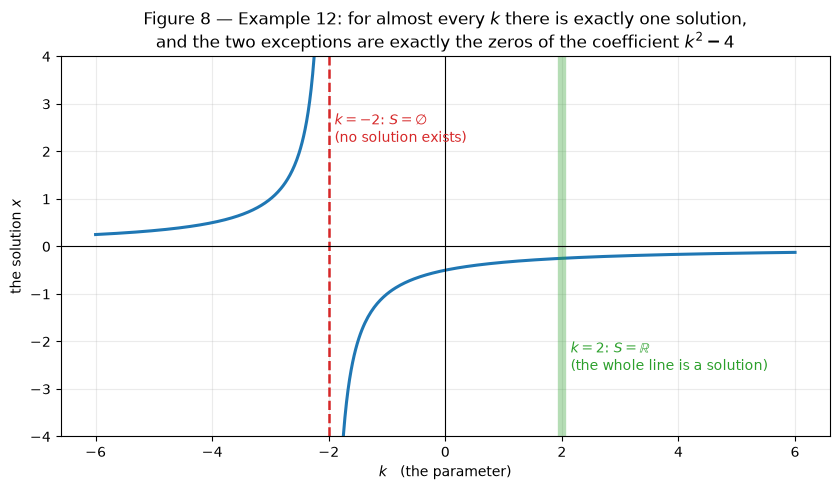

In [10]:
# --- Figure 8: Example 12 seen as a picture - the solution as k changes ---

fig, ax = plt.subplots(figsize=(8.5, 5.0))

# x = -1/(k+2) blows up at k = -2, so draw the two branches separately.
for piece in (np.linspace(-6.0, -2.12, 300), np.linspace(-1.88, 6.0, 300)):
    ax.plot(piece, -1.0 / (piece + 2.0), color=C_MAIN, linewidth=2.2)

# k = -2: no solution at all. Mark it with a red dashed wall.
ax.axvline(-2.0, color=C_BAD, linestyle="--", linewidth=1.8)
ax.text(-1.9, 2.2, r"$k=-2$: $S=\varnothing$" + "\n(no solution exists)",
        color=C_BAD, fontsize=10)

# k = 2: EVERY real number is a solution, so no single point can be drawn.
# Show it as a green vertical band instead.
ax.axvline(2.0, color=C_OK, linewidth=6, alpha=0.35)
ax.text(2.15, -2.6, r"$k=2$: $S=\mathbb{R}$" + "\n(the whole line is a solution)",
        color=C_OK, fontsize=10)

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("$k$   (the parameter)")
ax.set_ylabel("the solution $x$")
ax.set_title("Figure 8 — Example 12: for almost every $k$ there is exactly one solution,\n"
             "and the two exceptions are exactly the zeros of the coefficient $k^2-4$")
ax.set_ylim(-4.0, 4.0)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

---

## 6. Python demonstrations

New tools in this section:

* `sp.Eq(left, right)` — builds an **equation object**. Do **not** write `left == right`:
  in Python that asks "are these two expressions written the same way?", which is a
  different question and usually answers `False`.
* `sp.solve(eq, x)` — returns a **list** of solutions.
* `sp.solveset(eq, x, domain=sp.S.Reals)` — returns a **set**, which is the honest shape of
  the answer (Definition 4). It can say `EmptySet` and it can say `Reals`; a list cannot say
  either of those clearly.

### 6.1 The three shapes of Theorem 5, as Python sees them

In [11]:
# --- 6.1 one solution / no solution / every solution, in SymPy's own words ---

three_shapes = [
    ("one solution      ", sp.Eq(2*x + 1, 7)),          # Theorem 5, case 1
    ("no solution       ", sp.Eq(4*(x - 2), 4*x + 1)),  # Theorem 5, case 2
    ("every real number ", sp.Eq(3*(2*x - 1) + 4, 6*x + 1)),  # Theorem 5, case 3
]

for label, equation in three_shapes:
    as_set  = sp.solveset(equation, x, domain=sp.S.Reals)   # the SET answer
    as_list = sp.solve(equation, x)                         # the LIST answer
    print(f"{label} {str(equation):28} solveset -> {str(as_set):12} solve -> {as_list}")

print()
print("First, a detail: in the last two rows the 'equation' column prints False and True.")
print("That is SymPy telling you it already decided: 4(x-2)=4x+1 is impossible for every x,")
print("and 3(2x-1)+4=6x+1 is true for every x. Theorem 5, cases 2 and 3.")
print()
print("Now look carefully at the last two lines.")
print("solve() returns [] for BOTH 'no solution' and 'every number is a solution'.")
print("solveset() tells them apart: EmptySet versus Reals.")
print("This is why the answer to an equation is a SET, not a number - Definition 4.")

one solution       Eq(2*x + 1, 7)               solveset -> {3}          solve -> [3]
no solution        False                        solveset -> EmptySet     solve -> []
every real number  True                         solveset -> Reals        solve -> []

First, a detail: in the last two rows the 'equation' column prints False and True.
That is SymPy telling you it already decided: 4(x-2)=4x+1 is impossible for every x,
and 3(2x-1)+4=6x+1 is true for every x. Theorem 5, cases 2 and 3.

Now look carefully at the last two lines.
solve() returns [] for BOTH 'no solution' and 'every number is a solution'.
solveset() tells them apart: EmptySet versus Reals.
This is why the answer to an equation is a SET, not a number - Definition 4.


### 6.2 Checking a candidate — the right way and the lazy way

Corollary 6a made checking part of the proof. So it is worth doing it *properly*: substitute
into **both original sides** and compare **exactly**.

In [12]:
# --- 6.2 substitute and compare exactly ---

def check_candidate(lhs, rhs, value):
    """Substitute `value` for x in both sides and report honestly what happens."""
    try:
        left  = lhs.subs(x, value)     # .subs replaces the symbol x by the number
        right = rhs.subs(x, value)
    except ZeroDivisionError:
        return "NOT in the domain (division by zero)"
    # sp.simplify(left - right) == 0 is the exact test: is the difference really zero?
    if left.has(sp.zoo) or right.has(sp.zoo) or left.has(sp.nan) or right.has(sp.nan):
        # sp.zoo is SymPy's "complex infinity": what 1/0 becomes. It means: not in the domain.
        return "NOT in the domain (the expression blows up here)"
    if sp.simplify(left - right) == 0:
        return f"TRUE solution   (both sides = {sp.nsimplify(left)})"
    return f"false            (left = {left}, right = {right})"


# Example 9 - the candidate is genuine
print("Example 9:  3/(x+2) = 1/(x-1),  candidate x = 5/2")
print("   ->", check_candidate(3/(x + 2), 1/(x - 1), sp.Rational(5, 2)))

# Example 8 - the candidate is fake, and it is fake because E(2) = 0
print()
print("Example 8:  x/(x-2) = 2/(x-2) + 2,  candidate x = 2")
print("   ->", check_candidate(x/(x - 2), 2/(x - 2) + 2, 2))

Example 9:  3/(x+2) = 1/(x-1),  candidate x = 5/2
   -> TRUE solution   (both sides = 2/3)

Example 8:  x/(x-2) = 2/(x-2) + 2,  candidate x = 2
   -> NOT in the domain (the expression blows up here)


### 6.3 Watching Theorem 6 happen: SymPy is careful, hand-clearing is not

Here is the experiment. Take Example 8. Ask SymPy directly — it knows about domains and
answers `EmptySet`. Then do what a careless student does: multiply out the denominators
*yourself* and hand SymPy the polynomial equation. Now the fake solution appears, because
the information about the domain was thrown away in the step you did by hand.

The moral is not "SymPy is clever". The moral is: **the domain lives in the original
equation only.** The moment you clear denominators, it is gone from the paper, and the only
place it still exists is your head.

In [13]:
# --- 6.3 the fake solution appears exactly when we throw the domain away ---

lhs, rhs = x/(x - 2), 2/(x - 2) + 2
E = x - 2                                     # the expression we multiply by

honest = sp.solveset(sp.Eq(lhs, rhs), x, domain=sp.S.Reals)
print("Ask SymPy the ORIGINAL question :", honest)

# Now multiply both sides by E ourselves and tidy up - the dangerous move of Theorem 6.
# sp.cancel(...) does the cancelling that we would do by hand on paper.
cleared = sp.Eq(sp.cancel(E*lhs), sp.expand(sp.cancel(E*rhs)))
careless = sp.solveset(cleared, x, domain=sp.S.Reals)
print("After multiplying by (x-2)      :", cleared, " -> ", careless)

print()
print("Theorem 6 says  S' = S union Z  where Z is the zero set of E:")
Z = sp.solveset(sp.Eq(E, 0), x, domain=sp.S.Reals)
print("   S  (true solutions) =", honest)
print("   Z  (zeros of E)     =", Z)
print("   S union Z           =", sp.Union(honest, Z))
print("   S' (what we found)  =", careless)
print("   do they match?      ", sp.Union(honest, Z) == careless)

Ask SymPy the ORIGINAL question : EmptySet
After multiplying by (x-2)      : Eq(x, 2*x - 2)  ->  {2}

Theorem 6 says  S' = S union Z  where Z is the zero set of E:
   S  (true solutions) = EmptySet
   Z  (zeros of E)     = {2}
   S union Z           = {2}
   S' (what we found)  = {2}
   do they match?       True


In [14]:
# --- 6.4 write the theory as code: a solver that follows Theorems 3, 4 and 5 ---

def solve_linear(a, b):
    """Solve a*x + b = 0 exactly as Theorems 3 and 4 say, and return a SymPy set."""
    if a != 0:                       # Theorem 3: exactly one solution
        return sp.FiniteSet(sp.Rational(-b, a) if isinstance(a, int) and isinstance(b, int)
                            else -b/a)
    if b == 0:                       # Theorem 4, second case: every real number
        return sp.S.Reals
    return sp.S.EmptySet             # Theorem 4, first case: nothing works


tests = [(3, -6), (0, 0), (0, 5), (-2, 7), (1, 0)]
print(f"{'a':>4} {'b':>4}   ax + b = 0   ->  solution set")
print("-" * 52)
for a, b in tests:
    print(f"{a:>4} {b:>4}                 ->  {solve_linear(a, b)}")

print()
print("Now the same answers, checked against SymPy on the same equations:")
for a, b in tests:
    mine   = solve_linear(a, b)
    sympys = sp.solveset(sp.Eq(a*x + b, 0), x, domain=sp.S.Reals)
    print(f"   a={a:>3}, b={b:>3}:  mine = {str(mine):10}  sympy = {str(sympys):10}"
          f"  agree = {mine == sympys}")

   a    b   ax + b = 0   ->  solution set
----------------------------------------------------
   3   -6                 ->  {2}
   0    0                 ->  Reals
   0    5                 ->  EmptySet
  -2    7                 ->  {7/2}
   1    0                 ->  {0}

Now the same answers, checked against SymPy on the same equations:
   a=  3, b= -6:  mine = {2}         sympy = {2}         agree = True
   a=  0, b=  0:  mine = Reals       sympy = Reals       agree = True
   a=  0, b=  5:  mine = EmptySet    sympy = EmptySet    agree = True
   a= -2, b=  7:  mine = {7/2}       sympy = {7/2}       agree = True
   a=  1, b=  0:  mine = {0}         sympy = {0}         agree = True


### 6.5 Numerical-analysis lesson 7 — when $a$ is *almost* zero

Theorem 5 splits the world by asking one question: **is $a$ zero or not?** On paper that
question always has an answer. On a computer it does not.

Computers store numbers in *binary*, and most decimal fractions have no exact binary form —
exactly like $\tfrac13$ has no exact decimal form. So the computer keeps about 16 correct
digits and throws the rest away. That means a quantity that *should* be exactly $0$ can come
out as a tiny non-zero number instead.

Watch what that does to Theorem 5. If the true coefficient is $a=0$ and the true answer is
"no solution", but the computer computes $a \approx 5\times10^{-17}$, then it happily
reports one solution of size $10^{16}$ — a number that has nothing to do with the problem.

In [15]:
# --- 6.5 the classic: 0.1 + 0.2 is not 0.3 ---

print("0.1 + 0.2      =", 0.1 + 0.2)
print("0.3            =", 0.3)
print("are they equal?", 0.1 + 0.2 == 0.3)
print("the difference =", (0.1 + 0.2) - 0.3, "  <- should be exactly 0, but is not")

print()
print("Now feed that difference into Theorem 5 as the coefficient a:")
a_true = 0.0                            # what the mathematics says a is
a_float = (0.1 + 0.2) - 0.3             # what the computer thinks a is
b = -1.0

print(f"   exact  a = {a_true}   -> Theorem 4: b = -1 is not 0, so S = EmptySet")
print(f"   float  a = {a_float}")
print(f"   float  x = -b/a = {-b / a_float:.6e}   <- an answer invented by rounding")

print()
print("The fix is never to ask 'is a == 0?' with floats. Ask 'is a small compared")
print("with the other numbers in the problem?' - and say so in the code:")

def solve_linear_float(a, b, scale=1.0, tol=1e-12):
    """Solve a*x + b = 0 in floating point, refusing to trust a tiny a."""
    if abs(a) <= tol * max(1.0, abs(b), scale):    # a is zero as far as we can tell
        return "no solution (or every number, if b is 0 too) - a is numerically zero"
    return -b / a

print("   solve_linear_float(a_float, -1.0) ->", solve_linear_float(a_float, -1.0))
print("   solve_linear_float(3.0,     -6.0) ->", solve_linear_float(3.0, -6.0))

0.1 + 0.2      = 0.30000000000000004
0.3            = 0.3
are they equal? False
the difference = 5.551115123125783e-17   <- should be exactly 0, but is not

Now feed that difference into Theorem 5 as the coefficient a:
   exact  a = 0.0   -> Theorem 4: b = -1 is not 0, so S = EmptySet
   float  a = 5.551115123125783e-17
   float  x = -b/a = 1.801440e+16   <- an answer invented by rounding

The fix is never to ask 'is a == 0?' with floats. Ask 'is a small compared
with the other numbers in the problem?' - and say so in the code:
   solve_linear_float(a_float, -1.0) -> no solution (or every number, if b is 0 too) - a is numerically zero
   solve_linear_float(3.0,     -6.0) -> 2.0


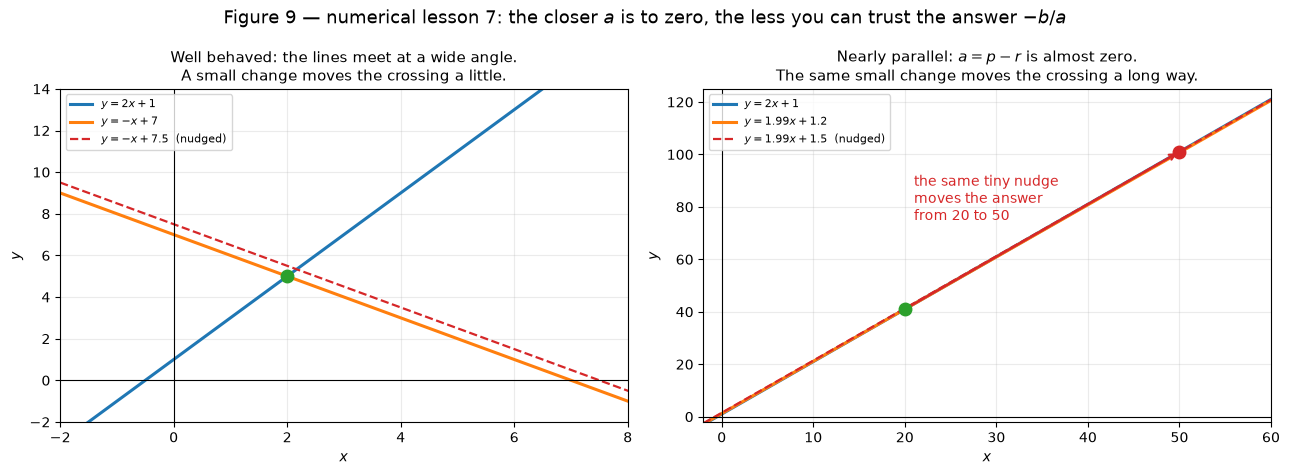

In [16]:
# --- Figure 9: why a tiny 'a' is dangerous - nearly parallel lines ---

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.8))
x_wide = np.linspace(-2.0, 60.0, 400)

# LEFT: two lines that cross at a clear angle. Nudging one barely moves the crossing.
axes[0].plot(x_wide, 2 * x_wide + 1, color=C_MAIN, linewidth=2.2, label=r"$y=2x+1$")
axes[0].plot(x_wide, -x_wide + 7,   color=C_ALT,  linewidth=2.2, label=r"$y=-x+7$")
axes[0].plot(x_wide, -x_wide + 7.5, color=C_BAD, linewidth=1.6, linestyle="--",
             label=r"$y=-x+7.5$  (nudged)")
axes[0].plot([2.0], [5.0], "o", color=C_OK, markersize=9, zorder=5)
axes[0].set_xlim(-2, 8)
axes[0].set_ylim(-2, 14)
axes[0].set_title("Well behaved: the lines meet at a wide angle.\n"
                  "A small change moves the crossing a little.", fontsize=11)

# RIGHT: two ALMOST parallel lines. The same nudge moves the crossing enormously.
axes[1].plot(x_wide, 2.00 * x_wide + 1, color=C_MAIN, linewidth=2.2, label=r"$y=2x+1$")
axes[1].plot(x_wide, 1.99 * x_wide + 1.2, color=C_ALT, linewidth=2.2,
             label=r"$y=1.99x+1.2$")
axes[1].plot(x_wide, 1.99 * x_wide + 1.5, color=C_BAD, linewidth=1.6, linestyle="--",
             label=r"$y=1.99x+1.5$  (nudged)")
axes[1].plot([20.0], [41.0], "o", color=C_OK, markersize=9, zorder=5)
axes[1].plot([50.0], [101.0], "o", color=C_BAD, markersize=9, zorder=5)
axes[1].annotate("", xy=(50, 101), xytext=(20, 41),
                 arrowprops=dict(arrowstyle="->", color=C_BAD, linewidth=1.6))
axes[1].text(21, 75, "the same tiny nudge\nmoves the answer\nfrom 20 to 50",
             color=C_BAD, fontsize=10)
axes[1].set_xlim(-2, 60)
axes[1].set_ylim(-2, 125)
axes[1].set_title("Nearly parallel: $a=p-r$ is almost zero.\n"
                  "The same small change moves the crossing a long way.", fontsize=11)

for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Figure 9 — numerical lesson 7: the closer $a$ is to zero, "
             "the less you can trust the answer $-b/a$", fontsize=13)
plt.tight_layout()
plt.show()

**What Figure 9 is really saying.** In the right-hand picture nothing is *wrong*: there is
exactly one solution, Theorem 3 holds, and the algebra is perfect. But the answer is
**unstable** — change the input a little and the answer changes a lot. Mathematicians call
such a problem **ill-conditioned**.

This matters far beyond this notebook. Later, when you solve systems of many equations at
once (and when you train a neural network, which is mostly that), "is this system
ill-conditioned?" is one of the first questions a scientist asks. You have now met the idea
in its smallest possible case: one equation, one unknown, and a coefficient $a$ that is
nearly zero.

---

## 7. Exercises — all 20 are for you

Rules of the house:

* **state the domain first**, every time;
* after every step, be able to name the theorem that allowed it;
* **check** whenever you multiplied, divided or squared by something containing $x$;
* write the answer as a **set**: $\{4\}$, $\varnothing$, $\mathbb{R}$;
* for the Python exercises, the cell must run on its own;
* for the proofs, write full sentences and name every axiom or theorem you use.

Do not look at Python before you have done the algebra by hand. Python is the referee, not
the player.

### Exercise 1 — is it linear?

For each equation, say whether it is **linear in $x$** (Definition 7 — can it be written as
$ax+b=0$ with $a \neq 0$?). If it is not, say in one sentence why not.

(a) $7x - 4 = 10$
(b) $\dfrac{3}{x} + 1 = 0$
(c) $(x+1)^2 = x^2 + 2x + 5$
(d) $\sqrt{x} = 2$
(e) $5 = 0\cdot x + 5$
(f) $\dfrac{x}{4} - \dfrac{2x-1}{3} = 6$

In [17]:
# your work for Exercise 1

### Exercise 2 — check, do not solve

Do **not** solve anything. Just decide, by substituting, whether the given number is a
solution. Show the arithmetic on both sides.

(a) Is $x = 3$ a solution of $4x - 5 = 2x + 1$?
(b) Is $x = -1$ a solution of $\dfrac{x+3}{x+1} = 2$?
(c) Is $x = 0$ a solution of $5(x-2) + 10 = 5x$?

In [18]:
# your work for Exercise 2

### Exercise 3 — the basic ones

Solve, and after each line write which theorem you used.

(a) $4x - 7 = 13$
(b) $2 - 5x = 17$
(c) $\dfrac{x}{3} + 4 = 1$

In [19]:
# your work for Exercise 3

### Exercise 4 — brackets and both sides

(a) $3(x-4) + 5 = 2(x+1)$
(b) $7 - 2(3x - 1) = 4x + 15$
(c) $6(x+2) - 4x = 2(x+6)$   *(look at your answer carefully before writing it down)*

In [20]:
# your work for Exercise 4

### Exercise 5 — clear the denominators

State the domain first. Then find the LCD and use Theorem 2.

(a) $\dfrac{x}{2} - \dfrac{x-1}{5} = \dfrac{3}{10}$
(b) $\dfrac{2x+1}{3} - \dfrac{x-4}{6} = 2$

In [21]:
# your work for Exercise 5

### Exercise 6 — decimals

(a) $0.4x - 0.15 = 0.25x + 0.3$
(b) $0.08x + 0.05(2000 - x) = 130$

For (b), also say in one sentence what real-life situation this equation could describe.

In [22]:
# your work for Exercise 6

### Exercise 7 — one, none, or all?

For each equation say which case of **Theorem 5** it is, and give the solution set.

(a) $2(x+3) = 2x + 6$
(b) $2(x+3) = 2x + 7$
(c) $2(x+3) = 3x + 6$

In [23]:
# your work for Exercise 7

### Exercise 8 — a fake solution

$$\frac{2}{x-3} + 1 = \frac{x-1}{x-3}$$

(a) Write the domain.
(b) Multiply by the LCD and solve, calling the answer a *candidate*.
(c) Check the candidate in the **original** equation.
(d) Write the solution set, and name the theorem that explains what happened.

In [24]:
# your work for Exercise 8

### Exercise 9 — a real solution (but still check it)

$$\frac{5}{x+1} = \frac{3}{x-1}$$

Domain, solve, check, solution set. In one sentence: why is checking still compulsory here,
even though the answer turns out to be genuine?

In [25]:
# your work for Exercise 9

### Exercise 10 — it looks harder than it is

(a) $(x-4)^2 = x^2 + 8$
(b) $(2x+1)(x-3) = 2x^2 - 5$

In each case, say at which moment the equation stopped being quadratic and became linear.

In [26]:
# your work for Exercise 10

### Exercise 11 — solve for the named letter

State any assumption you need (something must be non-zero for Theorem 2).

(a) $S = 2\pi r h + 2\pi r^{2}$, solve for $h$.
(b) $\dfrac{1}{f} = \dfrac{1}{u} + \dfrac{1}{v}$, solve for $v$. *(This is the lens formula
from physics.)*
(c) $y = \dfrac{2x+1}{x-3}$, solve for $x$. *(Collect the $x$-terms on one side and factor.)*

In [27]:
# your work for Exercise 11

### Exercise 12 — word problems

Translate into an equation, solve, and answer in a full sentence. Also state the hidden
domain (can the unknown be negative? a fraction?).

(a) The sum of three consecutive whole numbers is $72$. Find them.
(b) A triangle has a perimeter of $60$ cm. The second side is twice the first, and the third
is $5$ cm more than the first. Find the three sides. Then check that these three lengths can
really form a triangle (nb 03: the triangle inequality).

In [28]:
# your work for Exercise 12

### Exercise 13 — find the mistake

Here is a "solution" written by someone else:

> Solve $(x-3)(x+2) = 5(x-3)$.
> Divide both sides by $(x-3)$:  $x+2 = 5$.
> So $x = 3$… no wait, $x = 3$ is wrong, let me redo: $x = 5 - 2 = 3$.
> **Answer: $x = 3$.**

(a) There are **two** separate errors — one in the method and one in the arithmetic. Find
both.
(b) Solve the equation correctly.
(c) Which theorem of § 3.3 describes the method error, and what exactly was lost?

In [29]:
# your work for Exercise 13

### Exercise 14 — Python: your own solver

Write a function `solve_linear_equation(p, q, r, s)` that solves $px+q = rx+s$ and returns:

* the string `"one solution: x = ..."` with the exact fraction, when $p \neq r$;
* the string `"no solution"`, when $p=r$ and $q \neq s$;
* the string `"every real number"`, when $p=r$ and $q=s$.

Use `sp.Rational` so the answer stays exact (no decimals). Then test it on all three cases
and compare with `sp.solveset`. Your function must follow **Theorem 5**, not `sp.solve`.

In [30]:
# your work for Exercise 14

### Exercise 15 — Python: an extraneous-solution detector

Write a function `solve_and_check(lhs, rhs)` that:

1. finds the candidates by clearing denominators yourself (multiply both sides by the LCD
   and use `sp.cancel`);
2. substitutes each candidate back into the **original** `lhs` and `rhs`;
3. returns two lists: the genuine solutions, and the extraneous ones.

Test it on $\dfrac{x}{x-2} = \dfrac{2}{x-2}+2$ (Example 8) and on
$\dfrac{3}{x+2} = \dfrac{1}{x-1}$ (Example 9). Does your split agree with Theorem 6, i.e.
is every extraneous answer a zero of the thing you multiplied by?

In [31]:
# your work for Exercise 15

### Exercise 16 — Python: break it on purpose

(a) Build the coefficient `a = (0.1 + 0.2) - 0.3` and `b = -1.0`, then compute `-b/a`.
Print it.
(b) Now compute the same thing with `sp.Rational(1,10) + sp.Rational(2,10) -
sp.Rational(3,10)` and say what SymPy gives instead.
(c) In **two or three sentences of your own**: why does the float version invent an answer?
Which case of Theorem 5 is the true answer, and what does the computer's answer have to do
with the real problem? (This part matters more than the code.)

In [32]:
# your work for Exercise 16

### Exercise 17 — proof: the multiplication property

Prove **Theorem 2** yourself, without looking at § 3.1:

> If $c \neq 0$ is a real number, then $L(x)=R(x)$ and $c\,L(x) = c\,R(x)$ have the same
> solution set.

Write both inclusions. Then answer, in one sentence each:

(a) exactly which line of your proof breaks if $c = 0$;
(b) which axiom of $\mathbb{R}$ from nb 01 you used, and where.

In [33]:
# your work for Exercise 17

### Exercise 18 — proof: existence and uniqueness, in your own words

Let $a \neq 0$. Prove that $ax+b=0$ has exactly one solution.

Requirements:

* prove **existence** and **uniqueness** as two separate arguments;
* name the axiom or theorem for every step (there are at least four);
* in the uniqueness half, say clearly **where** you used $a \neq 0$ and **why** the argument
  collapses without it.

In [34]:
# your work for Exercise 18

### Exercise 19 — proof: the extraneous-solution theorem

Prove **Theorem 6**: with $S$, $S'$ and $Z$ as defined in § 3.3,
$$S' = S \cup Z .$$

Write both inclusions. State clearly which nb 01 theorem does the work in each direction —
they are not the same one.

Then use your theorem to answer this: someone multiplies both sides of an equation by
$E(x) = x^2+1$. How many extraneous solutions can appear? Prove your answer.

In [35]:
# your work for Exercise 19

### Exercise 20 — the hard one (three parts)

**(a)** Prove that a linear equation can never have **exactly two** solutions.
*Hint:* suppose $r \neq s$ are both solutions of $ax+b=0$ and reach a contradiction — or use
nb 04 Theorem 8 (a non-zero polynomial of degree $n$ has at most $n$ roots) and say why the
degree here is at most $1$.

**(b)** Prove the linear identity theorem: if two expressions $px+q$ and $rx+s$ give the
**same value at two different numbers** $x_1 \neq x_2$, then $p=r$ and $q=s$ — that is, they
are the same expression, and therefore agree everywhere.
*This is the exact statement behind "two different straight lines cannot cross twice"
(§ 1.4).*

**(c)** Give an equation with exactly two solutions, and explain in one sentence why parts
(a) and (b) do not apply to it.

In [36]:
# your work for Exercise 20

---

## 8. Say it back to me (no writing, just talking)

Answer these out loud, in your own words. If an answer takes more than four sentences, the
idea is not clear yet — come back to the section named in brackets.

1. What is the difference between an *expression* and an *equation*? Why is the answer to an
   equation a **set** and not a number? (§ 1.1, Definition 4)
2. What does it mean for two equations to be **equivalent**? Give two equations that look
   completely different but are equivalent. (Definition 6, Figure 4)
3. Theorem 2 says "$c \neq 0$". Point at the exact line of the proof that needs it, and say
   what goes wrong when $c=0$. (§ 3.1, Figure 5)
4. Why can a linear equation not have exactly two solutions? Answer with the *theorem*, not
   with a picture. (Theorem 5, and Exercise 20)
5. Theorem 6 says $S' = S \cup Z$. Explain what $Z$ is, and then explain why "check your
   answers" is a **step in the proof** rather than good manners. (§ 3.3, Corollary 6a)
6. Traps 1 and 3 look like opposites. One says *never divide by an expression*, the other
   says *always check after multiplying by one*. Why do the two dangerous moves have
   **opposite** dangers? (Theorem 6 vs Theorem 7)
7. The sharpest one: in Example 8 the algebra was perfect and the answer was still wrong.
   So what exactly *is* an algebra mistake, if perfect algebra can give a wrong answer?
   (§ 3.3, Trap 2)

---

## 9. Running this notebook with `uv`

This notebook needs nothing new. It uses **numpy** (arrays and fast arithmetic),
**matplotlib** (every picture) and **sympy** (exact algebra) — all three were already added
to the project in earlier notebooks.

```bash
uv sync                 # install exactly the dependencies listed in pyproject.toml
uv run jupyter lab      # start Jupyter and open notebooks/09-linear-equations.ipynb
```

Then in Jupyter: **Kernel → Restart Kernel and Run All Cells**. Everything must run from top
to bottom with no errors. If a cell fails, the failure is information — read the message
before changing anything.

### Where we go next

The syllabus chapter *Equations and Inequalities* continues like this, and every one of the
remaining topics leans on something we proved today:

| Next topic | What it needs from today |
| --- | --- |
| § 2 Quadratic Equations | the zero-product property, and "how many solutions?" as a real question |
| § 3 Complex Numbers | the honest gap: no real number squares to $-1$, so some quadratics have $S=\varnothing$ — we will build a bigger number system, for the sixth time |
| § 4 Radical Equations | **Corollary 6b**: squaring merges $L=R$ with $L=-R$, so every candidate must be checked |
| § 5 Inequalities | Theorems 1 and 2 again — but Theorem 2 changes! Multiplying an *inequality* by a negative number flips it |
| § 6 Absolute-value equations | nb 01's definition of $|x|$, split into cases |
| § 7 Applications | Example 13, many times over, with harder translations |

So the two theorems you proved today (add anything; multiply by a non-zero number) come back
in § 5 with one of them **broken**, and finding out exactly how it breaks is the whole point
of that topic. Keep this notebook nearby.